In [13]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "Math-3 Theory"
new_text = "sdfsd#@###3DDDfsa"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [14]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "DE Theory"
new_text = "Math-3 Theory"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [15]:
import json
import re

with open("de_eda.ipynb", "r", encoding="utf-8") as f:
    notebook = json.load(f)

old_text = "sdfsd#@###3DDDfsa"
new_text = "DE Theory"
pattern = re.compile(re.escape(old_text), re.IGNORECASE)

for cell in notebook["cells"]:
    if cell["cell_type"] in ("code", "markdown"):
        cell["source"] = [pattern.sub(new_text, line) for line in cell["source"]]

with open("de_eda.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1, ensure_ascii=False)


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Read the math train data
df = pd.read_csv("../train_dataset.csv")

# Drop the irrelevant, data leak columns
df = df.drop(
    columns=[
        "Student ID",
        "Mentor-1",
        "Mentor-2",
        "Mentor-3",
        "Roll-2",
        "Roll-3",
        "Math-3 Theory",
        "DE Practical",
        "FSD Theory",
        "FSD Practical",
        "Python Theory",
        "Python Practical",
        "Communication Theory",
        "Law Theory",
    ]
)

# columns for Semester 1 core subjects
sem1_columns = [
    "Math-1 Theory",
    "Physics Theory",
    "Java-1 Theory",
    "Software Engineering Theory",
]

# Calculate Semester 1 Percentage as the average of core subject scores
df["Sem 1 Percentage"] = df[sem1_columns].mean(axis=1).round(2)

# columns for Semester 2 core subjects
sem2_columns = [
    "Math-2 Theory",
    "Data Structures using Java Theory",
    "DBMS Theory",
    "Fundamental of Electronics and Electrical Theory",
    "Java-2 Theory",
]

# Calculate Semester 2 Percentage as the average of core subject scores
df["Sem 2 Percentage"] = df[sem2_columns].mean(axis=1).round(2)


# Rename columns Div-1, Div-2, Div-3 to Section-1, Section-2, Section-3
df = df.rename(
    columns={"Div-1": "Section-1", "Div-2": "Section-2", "Div-3": "Section-3"}
)

# Transform values in Section-1, Section-2, Section-3 to keep only the first character
for section in ["Section-1", "Section-2", "Section-3"]:
    df[section] = df[section].str[0]

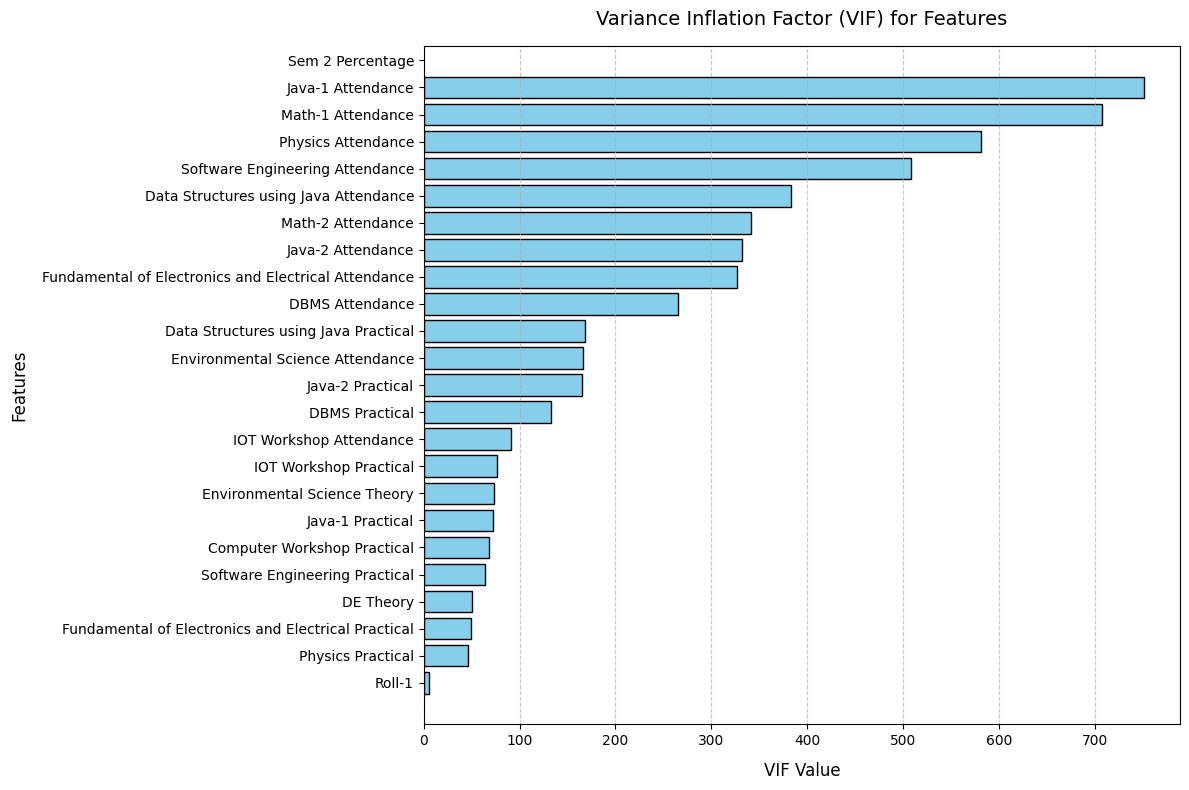

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
numeric_df = df.select_dtypes(include=["number"]).dropna()

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(numeric_df.values, i)
    for i in range(numeric_df.shape[1])
]

# Sort by VIF for clarity
vif_data = vif_data.sort_values("VIF", ascending=False)

# Plot the VIF values with better spacing
plt.figure(figsize=(12, 8))
bars = plt.barh(vif_data["Feature"], vif_data["VIF"], color="skyblue", edgecolor="black")

# Labels and title with padding
plt.xlabel("VIF Value", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.title("Variance Inflation Factor (VIF) for Features", fontsize=14, pad=15)

# Grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Invert y-axis so highest VIF is on top
plt.gca().invert_yaxis()

# Adjust layout for spacing
plt.tight_layout()
plt.show()


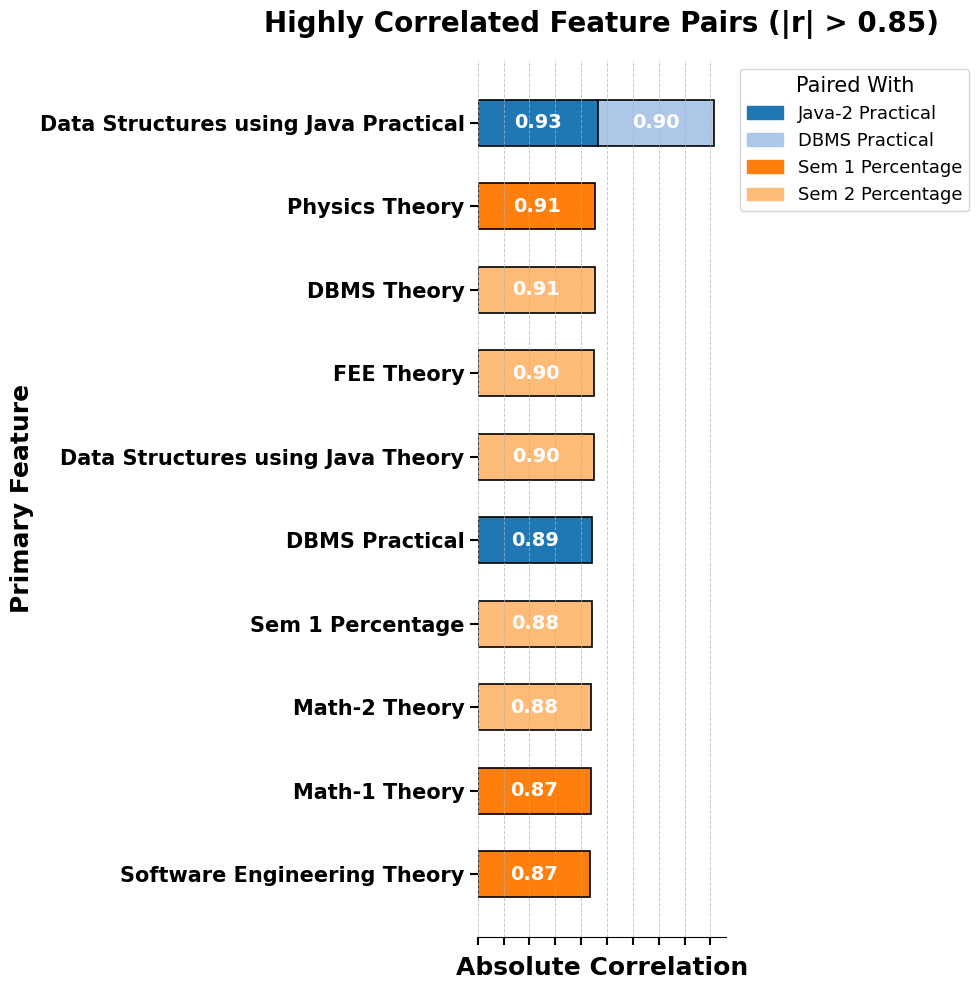

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) build correlation pairs (numeric-only columns) ---
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

threshold = 0.85
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only
pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
)
pairs.columns = ["Primary Feature", "Paired With", "Correlation"]
pairs = pairs[pairs["Correlation"].abs() > threshold].copy()
pairs["AbsCorr"] = pairs["Correlation"].abs()

if pairs.empty:
    raise ValueError(f"No correlated pairs found with |r| > {threshold}")

# --- 2) order Primary Features by their strongest correlation (desc) ---
order = (
    pairs.groupby("Primary Feature")["AbsCorr"]
    .max()
    .sort_values(ascending=False)
    .index
)
pairs["Primary Feature"] = pd.Categorical(
    pairs["Primary Feature"], categories=order, ordered=True
)

pairs = pairs.sort_values(["Primary Feature", "AbsCorr"], ascending=[True, False])

# --- 3) color mapping ---
unique_pairs = pairs["Paired With"].unique()
palette = sns.color_palette("tab20", n_colors=len(unique_pairs))
pair_color_map = {p: palette[i % len(palette)] for i, p in enumerate(unique_pairs)}

# --- Rename mapping for display ---
rename_map = {
    "Fundamental of Electronics and Electrical Theory": "FEE Theory"
}

# apply rename for plotting only
pairs["Primary Feature"] = pairs["Primary Feature"].replace(rename_map)
pairs["Paired With"] = pairs["Paired With"].replace(rename_map)

# also update 'order' to reflect renames
order = pd.Index([rename_map.get(o, o) for o in order])


# --- 4) plot ---
fig, ax = plt.subplots(figsize=(10, 10))  # reduced height, width same

for primary in order:
    row = pairs[pairs["Primary Feature"] == primary]
    left = 0.0
    for _, r in row.iterrows():
        val = r["AbsCorr"]
        pair = r["Paired With"]
        color = pair_color_map[pair]
        ax.barh(
            primary, val, left=left,
            height=0.55,  # thinner spacing between bars
            color=color, edgecolor="black", linewidth=1.2  # thicker edges
        )
        # add value annotation
        if val >= 0.06:
            ax.text(
                left + val / 2, primary, f"{val:.2f}",
                va="center", ha="center",
                fontsize=14, color="white", fontweight="bold"
            )
        left += val

# --- 5) aesthetics (extra bold text) ---
ax.set_xlabel("Absolute Correlation", fontsize=18, weight="bold")
ax.set_ylabel("Primary Feature", fontsize=18, weight="bold")
ax.set_title("Highly Correlated Feature Pairs (|r| > 0.85)",
             fontsize=20, weight="bold", pad=20)

ax.tick_params(axis="both", labelsize=15, width=1.5, length=6)  # thicker ticks
for label in ax.get_yticklabels() + ax.get_xticklabels():
    label.set_fontweight("bold")

ax.invert_yaxis()
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.7)
sns.despine(left=True, bottom=False)

# legend with bigger, bold fonts
handles = [plt.Rectangle((0, 0), 1, 1, color=pair_color_map[p]) for p in unique_pairs]
ax.legend(
    handles, unique_pairs, title="Paired With",
    bbox_to_anchor=(1.02, 1), loc="upper left",
    frameon=True, fontsize=13, title_fontsize=15
)

# x limit
max_total = pairs.groupby("Primary Feature")["AbsCorr"].sum().max()
ax.set_xlim(0, max(1.0, max_total) * 1.05)

# remove x-axis tick labels (annotations are enough)
ax.set_xticklabels([])

plt.tight_layout()
plt.show()


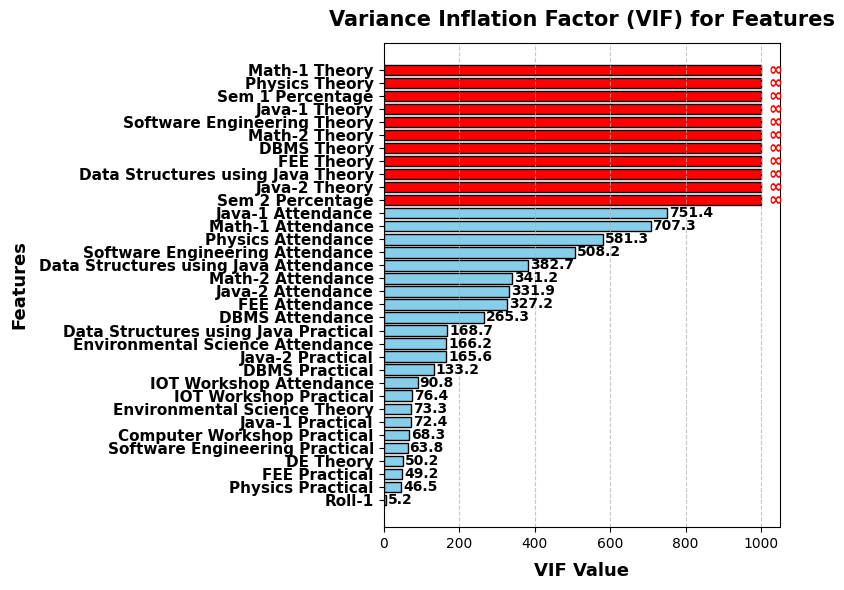

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
numeric_df = df.select_dtypes(include=["number"]).dropna()

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(numeric_df.values, i)
    for i in range(numeric_df.shape[1])
]

# Sort by VIF for clarity
vif_data = vif_data.sort_values("VIF", ascending=False)

# --- Rename mapping for cleaner display ---
rename_map = {
    "Fundamental of Electronics and Electrical Theory": "FEE Theory",
    "Fundamental of Electronics and Electrical Practical": "FEE Practical",
    "Fundamental of Electronics and Electrical Attendance": "FEE Attendance"  
}
vif_data["Feature"] = vif_data["Feature"].replace(rename_map)

# --- Cap inf values for plotting scale ---
cap_value = 1000  # upper cap for display
vif_data["VIF_plot"] = vif_data["VIF"].replace(np.inf, cap_value)

# --- Color map: red for inf, blue otherwise ---
colors = ["red" if np.isinf(v) else "skyblue" for v in vif_data["VIF"]]

# --- Plot with compact size ---
plt.figure(figsize=(8, 6))
bars = plt.barh(
    vif_data["Feature"], vif_data["VIF_plot"],
    color=colors, edgecolor="black"
)

# Add annotations: numbers or "∞"
for bar, vif in zip(bars, vif_data["VIF"]):
    if np.isinf(vif):
        plt.text(
            bar.get_width() + 20,  # shift to right
            bar.get_y() + bar.get_height()/2,
            "∞",
            va="center", ha="left",
            fontsize=12, fontweight="bold", color="red"
        )
    else:
        plt.text(
            bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f"{vif:.1f}",
            va="center", ha="left",
            fontsize=10, fontweight="bold", color="black"
        )

# Labels and title with bold text
plt.xlabel("VIF Value", fontsize=13, fontweight="bold", labelpad=8)
plt.ylabel("Features", fontsize=13, fontweight="bold", labelpad=8)
plt.title("Variance Inflation Factor (VIF) for Features",
          fontsize=15, fontweight="bold", pad=12)

# Bold y-axis feature labels
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(11)

# Grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Invert y-axis so highest VIF is on top
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [37]:
print(vif_data)

                                  Feature         VIF
1                           Math-1 Theory         inf
2                          Physics Theory         inf
32                       Sem 1 Percentage         inf
4                           Java-1 Theory         inf
6             Software Engineering Theory         inf
11                          Math-2 Theory         inf
14                            DBMS Theory         inf
16                             FEE Theory         inf
12      Data Structures using Java Theory         inf
18                          Java-2 Theory         inf
33                       Sem 2 Percentage         inf
22                      Java-1 Attendance  751.444958
20                      Math-1 Attendance  707.338958
21                     Physics Attendance  581.301743
23        Software Engineering Attendance  508.152499
27  Data Structures using Java Attendance  382.741382
26                      Math-2 Attendance  341.177485
30                      Java